<a href="https://colab.research.google.com/github/RyuuRong/Nueva-carpeta/blob/master/Automatizado_kpi_dashboard_final_v9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 1. Crear estructura de directorios ampliada hasta 2036
# Generamos la lista de años desde 2023 hasta 2036
YEARS = [str(year) for year in range(2023, 2037)]
BASE_PATH = '/content/smartfense_data'

for year in YEARS:
    path = os.path.join(BASE_PATH, year)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f'Carpeta creada: {path}')

print('\nEstructura lista. Puedes subir tus JSONs a cualquier carpeta hasta el año 2036.')

In [ ]:
import os
import json
import glob

def process_smartfense_json(year_folder):
    """Extrae datos de los archivos 'Interacciones de los usuarios en el tiempo' según la nueva guía."""
    summary = {
        'modulos': {'fin': 0, 'total': 0},
        'videos': {'fin': 0, 'total': 0},
        'juegos': {'fin': 0, 'total': 0},
        'examenes': {'fin': 0, 'total': 0},
        'newsletters': {'fin': 0, 'total': 0},
        'ransomware': {'fin': 0, 'total': 0},
        'phishing': {'clicks': 0, 'aperturas': 0, 'creds': 0, 'enviados': 0}
    }

    path = os.path.join(BASE_PATH, str(year_folder))

    # Mapeo de archivos y llaves
    mapeo = [
        ('*Módulos Interactivos Interacciones*', 'modulos', 'COMPLETED', 'SENT'),
        ('*Videos Interacciones*', 'videos', 'COMPLETED', 'SENT'),
        ('*Videojuegos Interacciones*', 'juegos', 'COMPLETED', 'SENT'),
        ('*Exámenes Interacciones*', 'examenes', 'PASS', 'SENT'),
        ('*Newsletters Interacciones*', 'newsletters', 'CORRECT_ANSWER', 'SENT'),
        ('*Ransomware Interacciones*', 'ransomware', 'DOWNLOAD', 'SENT'),
    ]

    for pattern, key, success_key, total_key in mapeo:
        files = glob.glob(os.path.join(path, pattern + ".json"))
        if files:
            with open(files[0], 'r', encoding='utf-8') as f:
                data = json.load(f)
                for mes in data:
                    summary[key]['fin'] += mes.get(success_key, 0)
                    summary[key]['total'] += mes.get(total_key, 0)

    # Phishing tiene mapeo múltiple
    phish_files = glob.glob(os.path.join(path, "*Phishing Interacciones*.json"))
    if phish_files:
        with open(phish_files[0], 'r', encoding='utf-8') as f:
            data = json.load(f)
            for mes in data:
                summary['phishing']['enviados'] += mes.get('SENT', 0)
                summary['phishing']['aperturas'] += mes.get('OPEN', 0)
                summary['phishing']['clicks'] += mes.get('CLICK', 0)
                summary['phishing']['creds'] += mes.get('POST', 0)

    return summary

In [ ]:
def generate_annual_dashboard(year):
    d = process_smartfense_json(year)
    if not d:
        print(f"No se encontraron datos procesables para {year}")
        return

    fig = plt.figure(figsize=(14, 7.2), facecolor='white')
    gs = fig.add_gridspec(2, 4, left=0.03, right=0.97, top=0.96, bottom=0.06, wspace=0.08, hspace=0.08)

    def get_pct(f, t): return f / t if t > 0 else 0

    def draw_card_local(ax, c, is_extended=False):
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        card = FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle="round,pad=0,rounding_size=0.06", linewidth=1.5, edgecolor="#B9B9B9", facecolor="white", mutation_scale=1)
        ax.add_patch(card)
        if not is_extended:
            ax.text(0.08, 0.90, c["title"], fontsize=10, fontweight='bold', color="#1B1B1B", va='top')
            ax.text(0.08, 0.62, c["value"], fontsize=30, fontweight='bold', color=c["main"], va='center')
            ax.text(0.08, 0.47, c["desc"], fontsize=10.5, color="#111111", va='top')
            if "badge" in c:
                badge = FancyBboxPatch((0.40, 0.58), 0.33, 0.12, boxstyle="round,pad=0.01,rounding_size=0.03", linewidth=0, facecolor=c["badge_color"])
                ax.add_patch(badge)
                ax.text(0.565, 0.64, c["badge"], ha='center', va='center', fontsize=8.5, color=c["badge_text"], fontweight='bold')
            bar_x, bar_y, bar_w, bar_h = 0.08, 0.23, 0.80, 0.035
            ax.add_patch(FancyBboxPatch((bar_x, bar_y), bar_w, bar_h, boxstyle="round,pad=0.005,rounding_size=0.02", facecolor=c["bar_bg"]))
            ax.add_patch(FancyBboxPatch((bar_x, bar_y), bar_w * c["progress"], bar_h, boxstyle="round,pad=0.005,rounding_size=0.02", facecolor=c["bar"]))
            ax.text(0.08, 0.15, c["label"], fontsize=9, color="#444444", va='center')
            ax.text(0.62, 0.15, c["pct"], fontsize=9, fontweight='bold', color="#111111", va='center')

    cards_data = [
        {"pos": (0, 0), "title": "MÓDULOS\nINTERACTIVOS", "value": f"{d['modulos']['fin']:,}", "desc": f"finalizados de {d['modulos']['total']:,}\nenviados", "label": "Tasa de finalización:", "pct": f"{int(get_pct(d['modulos']['fin'], d['modulos']['total'])*100)}%", "progress": get_pct(d['modulos']['fin'], d['modulos']['total']), "main": "#8B6BE8", "bar": "#8B6BE8", "bar_bg": "#E7E0F7"},
        {"pos": (0, 1), "title": "VIDEOS", "value": f"{d['videos']['fin']:,}", "desc": f"finalizados de {d['videos']['total']:,}\nenviados", "label": "Tasa de finalización:", "pct": f"{int(get_pct(d['videos']['fin'], d['videos']['total'])*100)}%", "progress": get_pct(d['videos']['fin'], d['videos']['total']), "main": "#8B6BE8", "bar": "#8B6BE8", "bar_bg": "#E7E0F7"},
        {"pos": (0, 2), "title": "VIDEOJUEGOS", "value": f"{d['juegos']['fin']:,}", "desc": f"finalizados de {d['juegos']['total']:,}\nenviados", "label": "Tasa de finalización:", "pct": f"{int(get_pct(d['juegos']['fin'], d['juegos']['total'])*100)}%", "progress": get_pct(d['juegos']['fin'], d['juegos']['total']), "main": "#8B6BE8", "bar": "#8B6BE8", "bar_bg": "#E7E0F7"},
        {"pos": (0, 3), "title": "EXÁMENES", "value": f"{d['examenes']['fin']:,}", "desc": f"aprobados de {d['examenes']['total']:,}\nenviados", "label": "Tasa de aprobación:", "pct": f"{int(get_pct(d['examenes']['fin'], d['examenes']['total'])*100)}%", "progress": get_pct(d['examenes']['fin'], d['examenes']['total']), "main": "#00A884", "bar": "#00A884", "bar_bg": "#D7F1EA"},
        {"pos": (1, 0), "title": "NEWSLETTERS", "value": f"{d['newsletters']['fin']:,}", "desc": f"correctas de {d['newsletters']['total']:,}\nenviadas", "label": "Tasa de respuesta:", "pct": f"{int(get_pct(d['newsletters']['fin'], d['newsletters']['total'])*100)}%", "progress": get_pct(d['newsletters']['fin'], d['newsletters']['total']), "main": "#00A884", "bar": "#00A884", "bar_bg": "#D7F1EA"},
        {"pos": (1, 1), "title": "RANSOMWARE", "value": f"{d['ransomware']['fin']:,}", "desc": f"ejecutado de {d['ransomware']['total']:,}\nenviados", "label": "Tasa de riesgo:", "pct": f"{int(get_pct(d['ransomware']['fin'], d['ransomware']['total'])*100)}%", "progress": get_pct(d['ransomware']['fin'], d['ransomware']['total']), "main": "#FF4B4B", "bar": "#F04C5C", "bar_bg": "#F7E1E3", "badge": "Riesgo bajo", "badge_color": "#DDEBCB", "badge_text": "#4E7A00"}
    ]

    for c in cards_data:
        ax = fig.add_subplot(gs[c["pos"]])
        draw_card_local(ax, c)

    axp = fig.add_subplot(gs[1, 2:4])
    draw_card_local(axp, None, is_extended=True)
    axp.text(0.05, 0.90, "PHISHING", fontsize=11, fontweight='bold', color="#1B1B1B", va='top')

    ph_click_pct = get_pct(d['phishing']['clicks'], d['phishing']['enviados'])
    ph_cred_pct = get_pct(d['phishing']['creds'], d['phishing']['enviados'])

    metrics = [
        (f"{d['phishing']['clicks']:,}", "Tasa de\nClicks", "#FF4B4B"),
        (f"{d['phishing']['aperturas']:,}", "Tasa de\nAperturas", "#F39C12"),
        (f"{d['phishing']['creds']:,}", "Credenciales\ningresadas", "#9B59B6"),
        (f"{d['phishing']['enviados']:,}", "Correos\nEnviados", "#3498DB")
    ]
    for i, (val, lbl, col) in enumerate(metrics):
        axp.text(0.05 + i*0.25, 0.72, val, fontsize=24, fontweight='bold', color=col)
        axp.text(0.05 + i*0.25, 0.60, lbl, fontsize=10.5, va='top', color="#111111")

    if ph_click_pct > 0.15 or ph_cred_pct > 0.05:
        ph_badge, ph_b_col, ph_t_col = "Riesgo alto", "#F7E1E3", "#FF4B4B"
    elif ph_click_pct > 0.05:
        ph_badge, ph_b_col, ph_t_col = "Riesgo moderado", "#FEF5E7", "#F39C12"
    else:
        ph_badge, ph_b_col, ph_t_col = "Riesgo bajo", "#DDEBCB", "#4E7A00"

    badge_ph = FancyBboxPatch((0.05, 0.38), 0.22, 0.08, boxstyle="round,pad=0.01,rounding_size=0.03", linewidth=0, facecolor=ph_b_col)
    axp.add_patch(badge_ph)
    axp.text(0.16, 0.42, ph_badge, ha='center', va='center', fontsize=8.5, color=ph_t_col, fontweight='bold')

    bar_w = 0.90; axp.add_patch(FancyBboxPatch((0.05, 0.22), bar_w, 0.04, boxstyle="round,pad=0.005", facecolor="#FDF2E9"))
    axp.add_patch(FancyBboxPatch((0.05, 0.22), bar_w * ph_click_pct, 0.04, boxstyle="round,pad=0.005", facecolor="#F39C12"))
    axp.text(0.05, 0.14, "Tasa general de riesgo", fontsize=10, color="#444444", va='center')
    axp.text(0.5, 0.14, f"{int(ph_click_pct*100)}%", fontweight='bold', ha='center', color="#111111")

    plt.savefig(f"dashboard_{year}.png", dpi=300, bbox_inches='tight')
    plt.show()

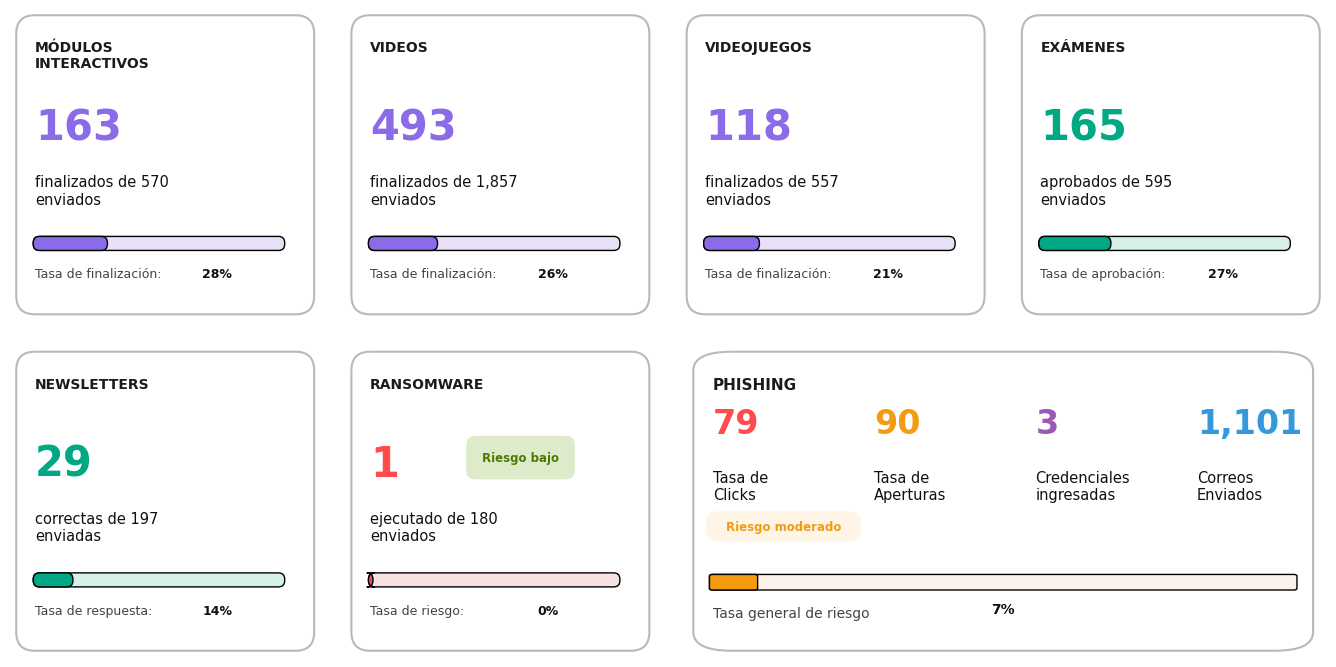

In [28]:
generate_annual_dashboard('2026')

### Generador de Gráficos por Año
Usa la celda de abajo para generar el dashboard del año que necesites. Asegúrate de haber subido los archivos JSON a la carpeta correcta en el panel de la izquierda.

Procesando datos para el año 2026...


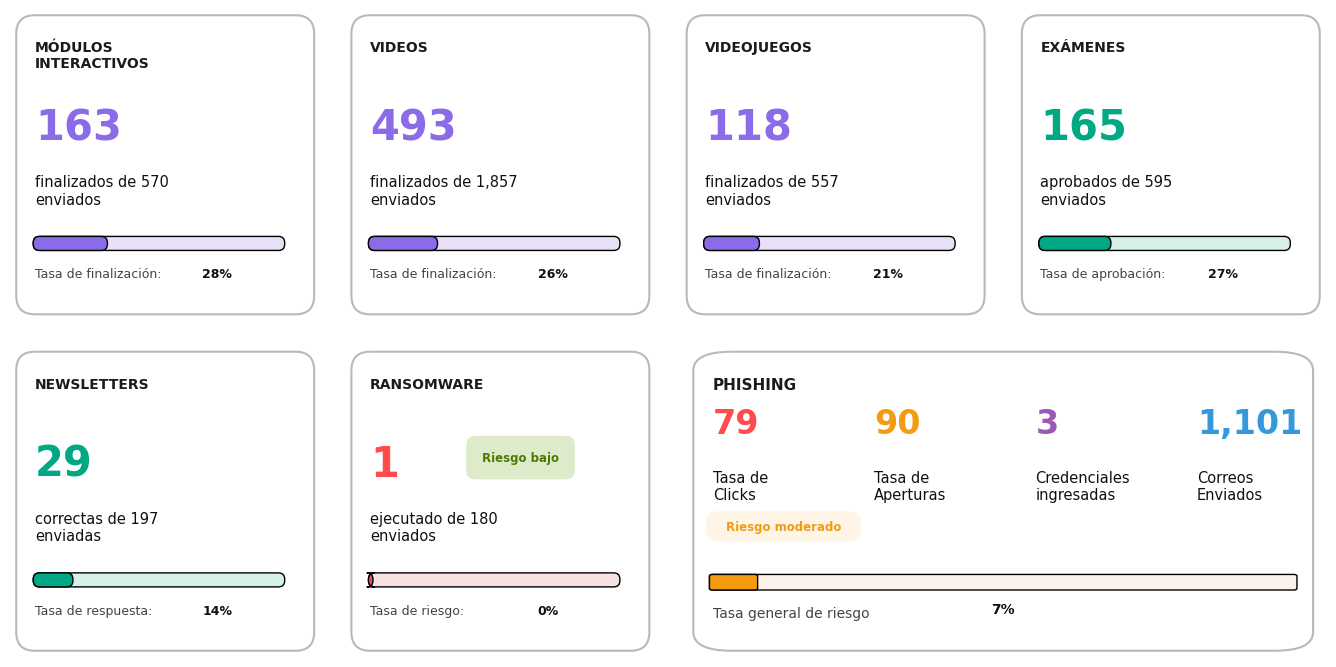

In [31]:
# @title Generar Dashboard Anual
# @markdown Selecciona el año y ejecuta esta celda para generar el reporte.

año_a_generar = "2026" # @param ["2023", "2024", "2025", "2026", "2027", "2028", "2029", "2030", "2031", "2032", "2033", "2034", "2035", "2036"] {allow-input: true}

# Ejecutar la automatización
print(f"Procesando datos para el año {año_a_generar}...")
generate_annual_dashboard(año_a_generar)

In [ ]:
import json
import os

# Inspeccionar el contenido de un archivo para ajustar la automatización
sample_path = '/content/smartfense_data/2026/Reporte de correlación de datos final.json'

if os.path.exists(sample_path):
    with open(sample_path, 'r') as f:
        data = json.load(f)
        print("Estructura detectada en el JSON:")
        print(json.dumps(data, indent=2)[:1000] + "...") # Mostramos el inicio para diagnosticar
else:
    print("No se encontró el archivo de reporte en la carpeta 2026. Por favor verifica el nombre.")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

plt.rcParams['font.family'] = 'DejaVu Sans'

fig = plt.figure(figsize=(14, 7.2))
fig.patch.set_facecolor('#ffffff')

# =========================================================
# GRID
# =========================================================

gs = fig.add_gridspec(
    2,
    4,
    left=0.03,
    right=0.97,
    top=0.96,
    bottom=0.06,
    wspace=0.08,
    hspace=0.08
)

# =========================================================
# TARJETAS NORMALES
# =========================================================

cards = [
    {
        "pos": (0, 0),
        "title": "MÓDULOS\nINTERACTIVOS",
        "value": "163",
        "desc": "finalizados de 570\nenviados",
        "label": "Tasa de finalización:",
        "pct": "29%",
        "progress": 0.29,
        "main": "#8B6BE8",
        "bar": "#8B6BE8",
        "bar_bg": "#E7E0F7",
    },
    {
        "pos": (0, 1),
        "title": "VIDEOS",
        "value": "493",
        "desc": "finalizados de 1,857\nenviados",
        "label": "Tasa de finalización:",
        "pct": "27%",
        "progress": 0.27,
        "main": "#8B6BE8",
        "bar": "#8B6BE8",
        "bar_bg": "#E7E0F7",
    },
    {
        "pos": (0, 2),
        "title": "VIDEOJUEGOS",
        "value": "118",
        "desc": "finalizados de 557\nenviados",
        "label": "Tasa de finalización:",
        "pct": "21%",
        "progress": 0.21,
        "main": "#8B6BE8",
        "bar": "#8B6BE8",
        "bar_bg": "#E7E0F7",
    },
    {
        "pos": (0, 3),
        "title": "EXÁMENES",
        "value": "165",
        "desc": "aprobados de 595\nenviados",
        "label": "Tasa de aprobación:",
        "pct": "28%",
        "progress": 0.28,
        "main": "#00A884",
        "bar": "#00A884",
        "bar_bg": "#D7F1EA",
    },
    {
        "pos": (1, 0),
        "title": "NEWSLETTERS",
        "value": "29",
        "desc": "correctas de 197\nenviadas",
        "label": "Tasa de respuesta:",
        "pct": "15%",
        "progress": 0.15,
        "main": "#00A884",
        "bar": "#00A884",
        "bar_bg": "#D7F1EA",
    },
    {
        "pos": (1, 1),
        "title": "RANSOMWARE",
        "value": "1",
        "desc": "ejecutado de 180\nenviados",
        "label": "Tasa de riesgo:",
        "pct": "1%",
        "progress": 0.01,
        "main": "#FF4B4B",
        "bar": "#F04C5C",
        "bar_bg": "#F7E1E3",
        "badge": "Riesgo bajo",
        "badge_color": "#DDEBCB",
        "badge_text": "#4E7A00"
    },
]

def draw_card(ax, c, is_extended=False):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    card = FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle="round,pad=0,rounding_size=0.06", linewidth=1.5, edgecolor="#B9B9B9", facecolor="white", mutation_scale=1)
    ax.add_patch(card)

    if not is_extended:
        ax.text(0.08, 0.90, c["title"], fontsize=10, fontweight='bold', color="#1B1B1B", va='top')
        ax.text(0.08, 0.62, c["value"], fontsize=30, fontweight='bold', color=c["main"], va='center')
        ax.text(0.08, 0.47, c["desc"], fontsize=10.5, color="#111111", va='top')
        if "badge" in c:
            badge = FancyBboxPatch((0.40, 0.58), 0.33, 0.12, boxstyle="round,pad=0.01,rounding_size=0.03", linewidth=0, facecolor=c["badge_color"])
            ax.add_patch(badge)
            ax.text(0.565, 0.64, c["badge"], ha='center', va='center', fontsize=8.5, color=c["badge_text"], fontweight='bold')
        bar_x, bar_y, bar_w, bar_h = 0.08, 0.23, 0.80, 0.035
        bg_bar = FancyBboxPatch((bar_x, bar_y), bar_w, bar_h, boxstyle="round,pad=0.005,rounding_size=0.02", linewidth=0, facecolor=c["bar_bg"])
        ax.add_patch(bg_bar)
        fill_bar = FancyBboxPatch((bar_x, bar_y), bar_w * c["progress"], bar_h, boxstyle="round,pad=0.005,rounding_size=0.02", linewidth=0, facecolor=c["bar"])
        ax.add_patch(fill_bar)
        ax.text(0.08, 0.15, c["label"], fontsize=9, color="#444444", va='center')
        ax.text(0.62, 0.15, c["pct"], fontsize=9, fontweight='bold', color="#111111", va='center')

for c in cards:
    r, col = c["pos"]
    ax = fig.add_subplot(gs[r, col])
    draw_card(ax, c)

# PHISHING EXTENDIDO
axp = fig.add_subplot(gs[1, 2:4])
draw_card(axp, None, is_extended=True)

axp.text(0.05, 0.92, "PHISHING", fontsize=11, fontweight='bold', color="#1B1B1B", va='top')

yellow_color = "#F39C12"
yellow_bg = "#FEF5E7"

metrics = [
    ("79", "Tasa de\nClicks", "#FF4B4B"),
    ("90", "Tasa de\nAperturas", yellow_color),
    ("3", "Credenciales\ningresadas", "#9B59B6"),
    ("1,101", "Correos\nEnviados", "#3498DB")
]
x_pos = [0.05, 0.30, 0.55, 0.80]
for (val, lbl, col), x in zip(metrics, x_pos):
    axp.text(x, 0.72, val, fontsize=24, fontweight='bold', color=col)
    axp.text(x, 0.60, lbl, fontsize=10.5, color="#111111", fontweight='normal', va='top')

# Ajuste del cuadro de badge: Color actualizado a amarillo (#F39C12)
b_x, b_y, b_w, b_h = 0.05, 0.34, 0.18, 0.12
badge = FancyBboxPatch((b_x, b_y), b_w, b_h, boxstyle="round,pad=0.01,rounding_size=0.02", linewidth=0, facecolor=yellow_bg)
axp.add_patch(badge)
axp.text(b_x + b_w/2, b_y + b_h/2, "Riesgo moderado", fontsize=8.5, ha='center', va='center', color=yellow_color, fontweight='bold')

bar_x, bar_y, bar_w, bar_h = 0.05, 0.20, 0.90, 0.04
bg_bar = FancyBboxPatch((bar_x, bar_y), bar_w, bar_h, boxstyle="round,pad=0.005,rounding_size=0.02", linewidth=0, facecolor="#FDF2E9")
axp.add_patch(bg_bar)
fill_bar = FancyBboxPatch((bar_x, bar_y), bar_w * 0.07, bar_h, boxstyle="round,pad=0.005,rounding_size=0.02", linewidth=0, facecolor=yellow_color)
axp.add_patch(fill_bar)
axp.text(0.05, 0.12, "Tasa general de riesgo", fontsize=10, color="#444444", va='center')
axp.text(0.48, 0.12, "7%", fontsize=10, fontweight='bold', color="#333333", ha='center', va='center')

plt.savefig("kpi_dashboard_final_v7.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [ ]:
from google.colab import files

# Ensure the plot is saved
output_filename = 'kpi_dashboard_final_v7.png'
fig.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

# Trigger download to local machine
files.download(output_filename)
print(f'Dashboard exported and download triggered: {output_filename}')